# Génération de 2 classes de points
*  @param {number} nbPoints - nombre total de points à générer.
*  Chaque ppoint a 3 caractéristiques : x, y, et type de classe  (0 pour la première classe et 1 pour la deuxième).

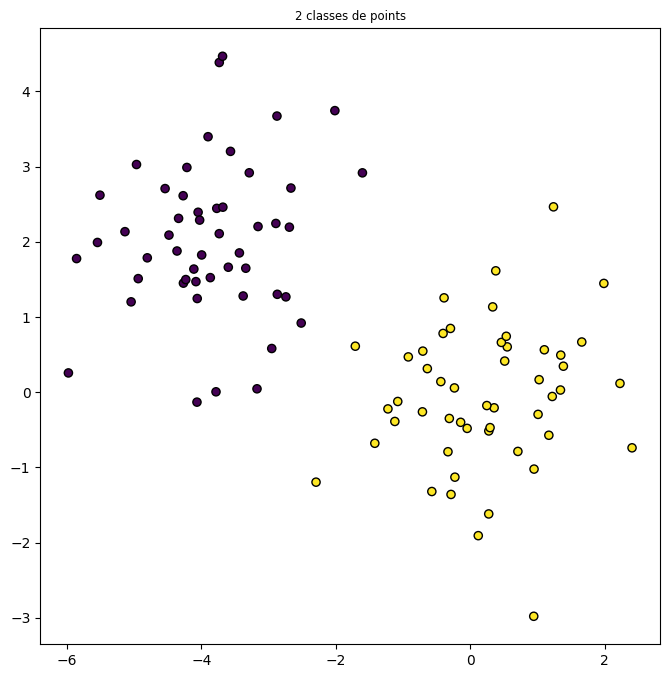

In [1]:
import matplotlib.pyplot as plt
#from pandas import DataFrame as df
from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles

plt.figure(figsize=(8, 8))
#plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)
Nb_points = 100
plt.subplot(111)
plt.title("2 classes de points", fontsize="small")
centers = [(-4, 2), (0, 0)] # centre des des classes
# création des 2 classes  
X1, Y1 = make_blobs(n_samples = Nb_points, cluster_std= 1, n_features=2, centers=centers, random_state=10,center_box=(-10.0, 10.0)) 

#df = df(dict(x=X1[:,0], y=X1[:,1], label=Y1))
# Converting DataFrame to a list containing
# all the rows of column 'Name'
#entree = df['x'].tolist()
#sortie = df['y'].tolist()
#label = df['label'].tolist()
#print(X1[:,0])
#print(X1[:,0].shape)
#print(X1.shape[0])
#Xe = X1.reshape(Nb_points*2)

# Xe et Xs sont dans un premier temps les entrées et sorties du réseau 
Xe = X1[:,0]
Xs = X1[:,1]
#print(Xe)
#print()
#A = X1[:, ::-1]# inverse l'ordre des éléments
#print(A)

# tracé des points sur le graphe avec  leur étiquette correspondante en couleur
plt.scatter(X1[:, 0], X1[:, 1], marker="o",c=Y1, s=35, edgecolor="k")
plt.show()

# Création du réseau séquentiel avec des fonctions d'activation identité (linéaire)

In [2]:
from keras.models import Sequential 
from keras.layers import Activation, Dense 
from keras import initializers
from keras.optimizers import SGD, Adam
import numpy as np 

my_init = initializers.Zeros() 
#my_init = initializers.Ones()
#my_init = initializers.RandomUniform(minval=0.0, maxval=1.0)
#normalizer = preprocessing.Normalization()
model=Sequential()
#pour La couche d'entrée, input_shape doit être égale à 1 + couche 3 neurones units = 3
model.add(Dense(units=1,input_shape=[1],activation= 'linear',kernel_initializer = my_init))
#Couche intermédiaire
#model.add(Dense(units=1,activation= 'linear'))
#model.add(Dense(units=64,activation= 'linear'))
#model.add(Dense(units=64,activation= 'linear'))
#model.add(Dense(units=64))
#La couche de sortie, units vaut 1
#model.add(Dense(units=1, activation='linear'))
#Création du réseau ("adam "alternatif à "sgd")
#opt = SGD(lr=0.01) #w = w - learning_rate * g
opt = Adam(learning_rate=0.1)
model.compile(loss='mean_squared_error',optimizer=opt, metrics=['mean_squared_error'])
entree = Xe
sortie = Xs

#Entraînement du réseau 1000 passages (1000 époques)
model.fit(x=entree,y=sortie,epochs=200)

#Affichage des poids
print("")
print("Weights: \n")
print(model.get_weights())

#Prédire les nombres
liste_x= np.linspace(-6,2, num =50)
xe = np.array([[x] for x in liste_x])
prediction = model.predict(xe)

# on obtient une régression linéaire ! on n'a pas séparé les classes de 2 points !

Epoch 1/200
4/4 [==============================] - 0s 2ms/step - loss: 2.3663 - mean_squared_error: 2.3663
Epoch 2/200
4/4 [==============================] - 0s 2ms/step - loss: 1.3553 - mean_squared_error: 1.3553
Epoch 3/200
4/4 [==============================] - 0s 2ms/step - loss: 1.6186 - mean_squared_error: 1.6186
Epoch 4/200
4/4 [==============================] - 0s 2ms/step - loss: 1.3771 - mean_squared_error: 1.3771
Epoch 5/200
4/4 [==============================] - 0s 2ms/step - loss: 1.2894 - mean_squared_error: 1.2894
Epoch 6/200
4/4 [==============================] - 0s 2ms/step - loss: 1.3540 - mean_squared_error: 1.3540
Epoch 7/200
4/4 [==============================] - 0s 2ms/step - loss: 1.2761 - mean_squared_error: 1.2761
Epoch 8/200
4/4 [==============================] - 0s 2ms/step - loss: 1.3753 - mean_squared_error: 1.3753
Epoch 9/200
4/4 [==============================] - 0s 2ms/step - loss: 1.4191 - mean_squared_error: 1.4191
Epoch 10/200
4/4 [===================

# Tracé du graphe ...

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


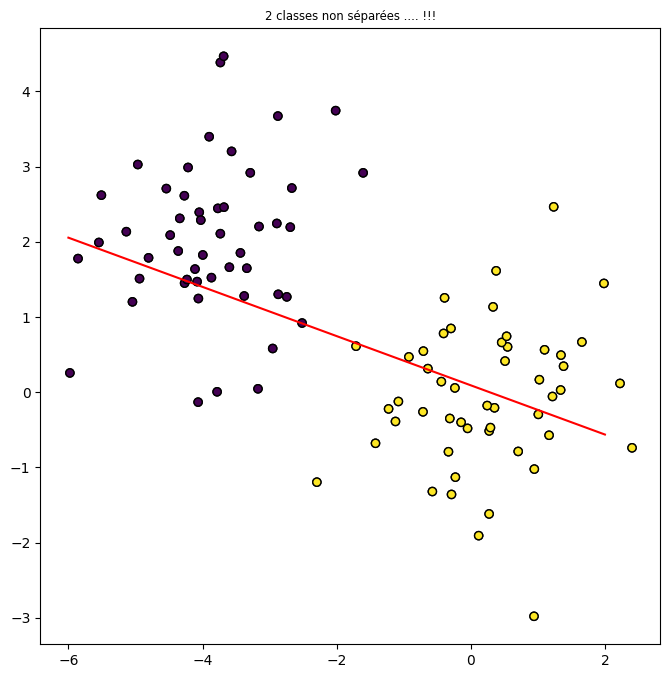

In [3]:
import matplotlib.pyplot as plt
#from pandas import DataFrame as df
from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles

plt.figure(figsize=(8, 8))
#plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)
Nb_points = 100
#plt.subplot(111)
plt.title("2 classes non séparées .... !!!", fontsize="small")
centers = [(-4, 2), (0, 0)]
X1, Y1 = make_blobs(n_samples = Nb_points, cluster_std= 1, n_features=2, centers=centers, random_state=10,center_box=(-10.0, 10.0))

Xe = X1[:,0]
Xs = X1[:,1]

#print()
#A = X1[:, ::-1]
#print(A)
plt.scatter(X1[:, 0], X1[:, 1], marker="o",c=Y1, s=35, edgecolor="k")
#print(A)
plt.scatter(X1[:, 0], X1[:, 1], marker="o",c=Y1, s=35, edgecolor="k")
plt.plot(liste_x,prediction,color = 'r')
model.summary()
plt.show()
plt.show()

# Modifions le réseau de neurones pour réaliser une classification
* on travaille avec une  couche d'entrée (input) de dimension 2
* et une couche de sortie (output) de dimension 1 qui sera la classe.
* la fonction d'activation pour le dernière couche et le fonction sigmoïde

In [4]:
from keras.models import Sequential 
from keras.layers import Activation, Dense 
from keras import initializers
from keras.optimizers import SGD, Adam
import numpy as np 

#my_init = initializers.Zeros() 
my_init = initializers.Ones()
#my_init = initializers.RandomUniform(minval=0.0, maxval=1.0)
#normalizer = preprocessing.Normalization()
model=Sequential()
#pour La couche d'entrée, input_shape vaut : 2  (car on a 2 features: x et y), pas de normalisation nécessaire
model.add(Dense(units=1,input_shape=[2],activation= 'sigmoid',kernel_initializer = my_init))

#La couche de sortie, units vaut 1 mais activation sigmoïde
# model.add(Dense(units=1, activation='sigmoid'))

#Création du réseau ("adam "alternatif à "sgd")
#opt = SGD(lr=0.01) #w = w - learning_rate * g
opt = Adam(learning_rate=0.01)
model.compile(loss='mean_squared_error',optimizer=opt,  metrics=['accuracy'])
# entrée de dimension 2 (x, y)
entree = X1
# sortie de dimension  1 (classe bipolaire)
sortie = Y1

#Entraînement du réseau 1000 passages
history = model.fit(x=entree,y=sortie,epochs=100)

#Print weights
print("")
print("Weights: \n")
W = model.get_weights()
w1 = W[0][0][0]
w2 = W[0][1][0]
b1 = W[1][0]
print(model.get_weights())
print(W[0][0][0])
print(W[0][1][0])
print(W[1][0])
#Prédire l'appartenance de points à un classe : 
#print(X1)
A= [[2,2]]
B= [[-4,2]]
print(model.predict(A))
print(model.predict(B))
print( A[0][1])

print('prediction A :')
print(model.predict(A))
print('prédiction B :')
print(model.predict(B))

Epoch 1/100
4/4 [==============================] - 0s 1ms/step - loss: 0.1916 - accuracy: 0.6900
Epoch 2/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1821 - accuracy: 0.7100
Epoch 3/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1742 - accuracy: 0.7100
Epoch 4/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1670 - accuracy: 0.7300
Epoch 5/100
4/4 [==============================] - 0s 1ms/step - loss: 0.1598 - accuracy: 0.7500
Epoch 6/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1532 - accuracy: 0.7600
Epoch 7/100
4/4 [==============================] - 0s 1ms/step - loss: 0.1474 - accuracy: 0.7600
Epoch 8/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1416 - accuracy: 0.7700
Epoch 9/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1362 - accuracy: 0.7700
Epoch 10/100
4/4 [==============================] - 0s 2ms/step - loss: 0.1314 - accuracy: 0.7700
Epoch 11/100
4/4 [===========

# Visualisons l'évolution des erreurs et de la précision du modèle sur les données d'entrainement

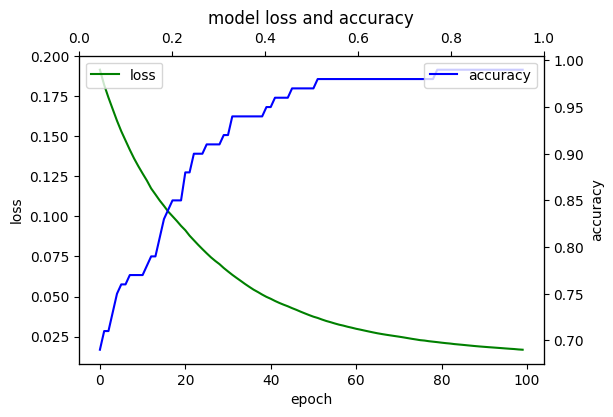

In [5]:
# list all data in history
#print(history.history.keys())
# Représentation d'un nuage de points
#fig, ax1 = plt.subplots(1, 1,num="Etude cinétique d'un oscillateur libre", figsize=(7, 4), dpi=100, facecolor='w', layout='constrained')# subplots peut permettre de créer plusieurs graphes dans une même figure 
# 
fig, ax1 = plt.subplots(figsize=(6, 4))
#plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)
ax2 = ax1.twiny()

plt.title('model loss and accuracy')
ax1.plot(history.history['loss'], 'g-', label = 'loss')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()

ax2.plot(history.history['accuracy'], 'b-', label ='accuracy')
ax2.set_ylabel('accuracy')
ax2.legend(loc='upper right')
plt.show()

# Tracé des graphes avec les prédictions pour deux tests A et B

prediction A :
1/1 [==============================] - 0s 38ms/step
[[0.96382356]]
prédiction B :
1/1 [==============================] - 0s 34ms/step
[[0.03675716]]


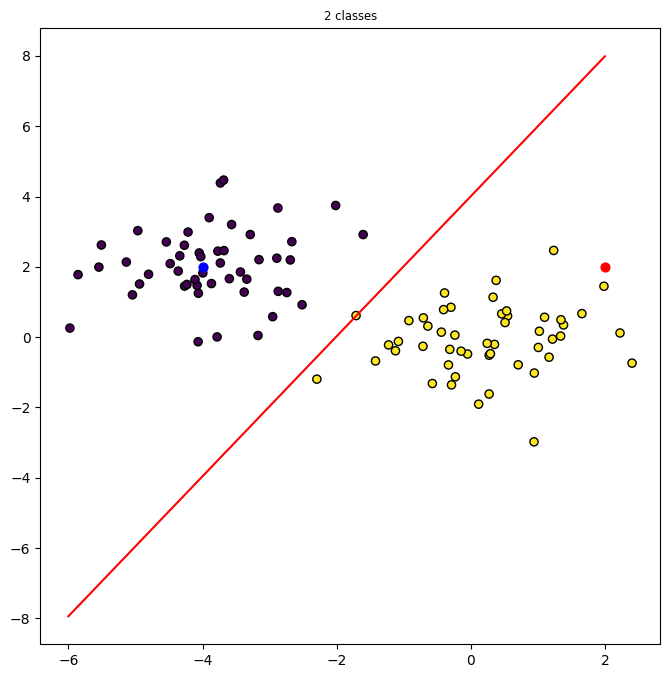

In [6]:
print('prediction A :')
print(model.predict(A))
print('prédiction B :')
print(model.predict(B))

plt.figure(figsize=(8, 8))
#plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

plt.subplot(111)
plt.title("2 classes", fontsize="small")

#print(A)
plt.scatter(X1[:, 0], X1[:, 1], marker="o",c=Y1, s=35, edgecolor="k",cmap='viridis')
plt.scatter(A[0][0], A[0][1], marker="o",c='red', s=40, edgecolor="red")
plt.scatter(B[0][0], B[0][1], marker="o",c='blue', s=40, edgecolor="blue")

#Prédire les nombres
liste_x= np.linspace(-6,2, num =50)
xe = np.array([[x] for x in liste_x])
#Ylim = (-xe*1.0792954 - 2.191928)/(-0.56038827)
Ylim = (-xe*w1 - b1)/(w2)

plt.plot(xe,Ylim,color = 'r')
#model.summary()
plt.show()


# Matrice de confusion
- Aussi appelée tableau de contingence, la matrice de confusion permet d'évaluer les performances d'un modèle de classification.  
Elle montre donc à quel point un certain modèle peut être confus lorsqu'il fait des prédictions.

4/4 [==============================] - 0s 1ms/step
[[50  0]
 [ 1 49]]


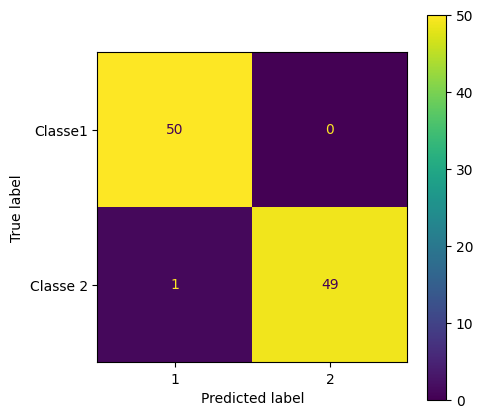

In [7]:
#from sklearn.metrics import confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

#print(Y1)
Y1_pred = model.predict(X1)

Y1_pred_round = np.round(Y1_pred) # arrondir
cf = metrics.confusion_matrix(Y1,Y1_pred_round)

print(cf)
#cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = metrics.confusion_matrix, display_labels = [False, True])
#ConfusionMatrixDisplay.from_predictions(expected, predicted)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(Y1, Y1_pred_round, ax=ax)
ax.xaxis.set_ticklabels(['1','2'])
ax.yaxis.set_ticklabels(['Classe1', 'Classe 2'])
plt.show()



# Quelques lignes de code pour tracer les différentes zones de classification

4/4 [==============================] - 0s 1ms/step


(<Figure size 640x480 with 1 Axes>, <Axes: >)

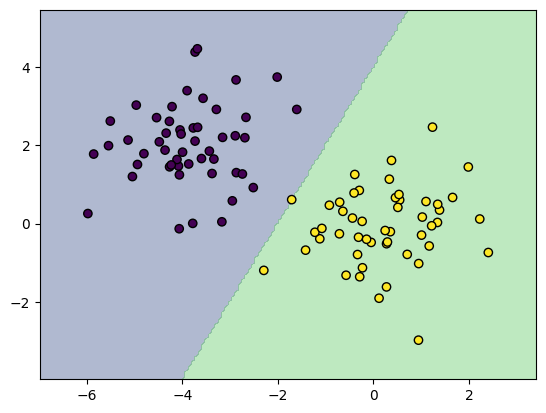

In [8]:
import matplotlib as mpl
def plot_decision_boundary(X, y, model, steps=150, cmap='Paired', alpha =0.5):
    """
    Function to plot the decision boundary and data points of a model.
    Data points are colored based on their actual label.
    """
    alpha = alpha
    # Define region of interest by data limits
    xmin, xmax = X[:,0].min() - 1, X[:,0].max() + 1
    ymin, ymax = X[:,1].min() - 1, X[:,1].max() + 1
    steps = steps
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    # Make predictions across region of interest
    labels = model.predict(np.c_[xx.ravel(), yy.ravel()])#ravel renvoie un tableau 1D.... np.c_ contatene les tableaux suivant les colonnes 
    #print(labels)
    # Plot decision boundary in region of interest
    #print("dim xx shape : ",xx.shape)
    z = labels.reshape(xx.shape) # z est obtenu en redimensionant  labels (steps, steps)
    #print(z)
    z =  z > 0.5 #(Threshold value)
    #print(z)
    fig, ax = plt.subplots()
    ax.contourf(xx, yy, z, cmap=cmap, alpha=alpha)

    # Get predicted labels on training data and plot
    train_labels = model.predict(X)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, lw=1,edgecolor="k")
    
    return fig, ax

#cmap = plt.get_cmap('viridis',lut=5)
#cmap = (mpl.colors.ListedColormap(['red', 'green', 'blue']).with_extremes(over='0.0', under='1'))
#cmap='RdBu'
#cmap = (mpl.colors.ListedColormap(['red','red', 'white', 'blue','blue'])
#        .with_extremes(under='orange', over='magenta'))
#bounds = [0, 0.18, 0.52, 1]
#norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
cmap='viridis'
plot_decision_boundary(X1, Y1, model, cmap=cmap, alpha=0.4)

# autre méthode pour tracer les zones....

79/79 [==============================] - 0s 1ms/step


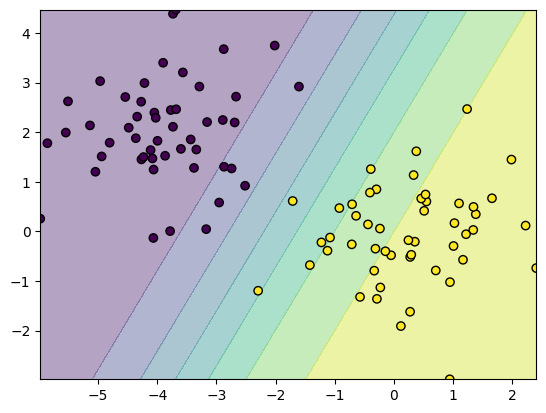

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

# Define region of interest by data limits
xmin, xmax = X1[:,0].min() - 1, X1[:,0].max() + 1
ymin, ymax = X1[:,1].min() - 1, X1[:,1].max() + 1
steps = 100
x_span = np.linspace(xmin, xmax, steps)
y_span = np.linspace(ymin, ymax, steps)
xx, yy = np.meshgrid(x_span, y_span)

feature_1, feature_2 = np.meshgrid(np.linspace(X1[:, 0].min(), X1[:, 0].max()),np.linspace(X1[:, 1].min(), X1[:, 1].max()))
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
y_pred = np.reshape(model.predict(grid), feature_1.shape)
display = DecisionBoundaryDisplay(xx0=feature_1, xx1=feature_2, response=y_pred)
#cmap = matplotlib.colors.ListedColormap(["gold", "white", "indigo"])
cmap = plt.get_cmap('viridis',lut=3)
#cmap='viridis'
display.plot(alpha =0.4)
display.ax_.scatter(X1[:, 0], X1[:, 1], c=Y1, edgecolor="black", cmap =cmap)
plt.show()